Silakan unggah satu file gambar (misalnya, gambar Kucing atau Anjing) untuk melihat visualisasi Fitur Lokal:


Saving 0EDJQLHJB3U3.jpg to 0EDJQLHJB3U3.jpg

 VISUALISASI TAHAP AWAL BAG OF VISUAL WORDS (BOVW)

1. Deteksi Titik Kunci (Keypoints):
Total Keypoints Ditemukan: 500


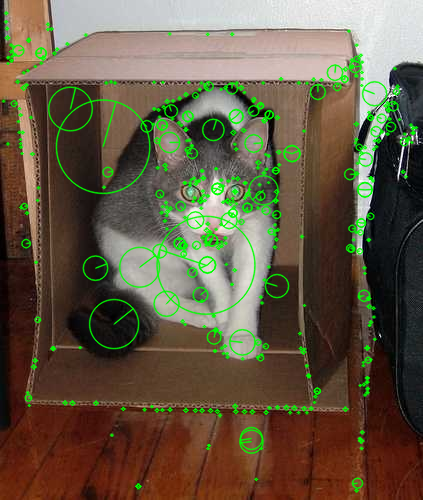


2. Simulasi Visualisasi Area Lokal (Patch Sekitar Keypoint Terkuat):
   Area ini yang akan diubah SIFT menjadi Histogram Gradien (Deskriptor).


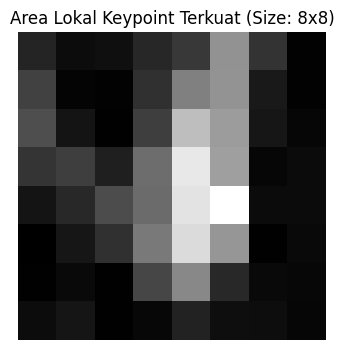


--- KESIMPULAN ALUR BOVW ---
Langkah 1: Titik Kunci terdeteksi (ditandai hijau).
Langkah 2: Area sekitar titik kunci dideskripsikan (seperti patch di atas).
Langkah 3: Semua Deskriptor ini dikelompokkan (Clustering/K-Means) untuk membuat Kosa Kata Visual (Visual Vocabulary).
Langkah 4: Setiap gambar diubah menjadi Histogram (vektor frekuensi kata visual).
Langkah 5: Histogram ini digunakan untuk melatih Classifier (SVM).


In [1]:
import cv2
import numpy as np
from google.colab import files
from google.colab.patches import cv2_imshow
from matplotlib import pyplot as plt

# --- 1. SETTING DAN UPLOAD GAMBAR ---

print("Silakan unggah satu file gambar (misalnya, gambar Kucing atau Anjing) untuk melihat visualisasi Fitur Lokal:")
uploaded = files.upload()

if not uploaded:
    print("Error: Harap unggah file gambar.")
else:
    filename = next(iter(uploaded))
    img_bgr = cv2.imdecode(np.frombuffer(uploaded[filename], np.uint8), cv2.IMREAD_COLOR)

    if img_bgr is None:
        print("Error: File tidak dapat dibaca sebagai gambar.")
    else:
        # Konversi ke Grayscale (Wajib untuk SIFT/ORB)
        img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

        # --- 2. DETEKSI TITIK KUNCI (Keypoint Detection) ---

        # Menggunakan SIFT sebagai detektor/deskriptor yang umum untuk BoW
        sift = cv2.SIFT_create(nfeatures=500)

        # Deteksi Keypoints dan Komputasi Deskriptor
        kp, des = sift.detectAndCompute(img_gray, None)

        # Visualisasi Titik Kunci
        img_keypoints = cv2.drawKeypoints(img_bgr.copy(), kp, None, color=(0, 255, 0), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

        # --- 3. VISUALISASI HASIL ---

        print("\n=============================================")
        print(" VISUALISASI TAHAP AWAL BAG OF VISUAL WORDS (BOVW)")
        print("=============================================")

        print("\n1. Deteksi Titik Kunci (Keypoints):")
        print(f"Total Keypoints Ditemukan: {len(kp)}")
        cv2_imshow(img_keypoints)

        # Untuk visualisasi gradien lokal SIFT (mirip dengan slide Anda sebelumnya),
        # kita menggunakan fungsi matplotlib untuk menampilkan patch sekitar keypoint.

        if len(kp) > 0:
            # Mengambil keypoint yang paling kuat
            best_kp = sorted(kp, key=lambda x: x.response, reverse=True)[0]

            # Mendefinisikan area di sekitar keypoint
            x, y = best_kp.pt
            size = int(best_kp.size * 5)
            x, y = int(x), int(y)

            # Memastikan patch berada dalam batas gambar
            start_x = max(0, x - size // 2)
            end_x = min(img_gray.shape[1], x + size // 2)
            start_y = max(0, y - size // 2)
            end_y = min(img_gray.shape[0], y + size // 2)

            patch = img_gray[start_y:end_y, start_x:end_x]

            if patch.shape[0] > 0 and patch.shape[1] > 0:
                 # Simulasikan Visualisasi Gradien Lokal (Deskriptor)
                 print("\n2. Simulasi Visualisasi Area Lokal (Patch Sekitar Keypoint Terkuat):")
                 print("   Area ini yang akan diubah SIFT menjadi Histogram Gradien (Deskriptor).")

                 # Untuk visualisasi yang lebih baik, kita gunakan Matplotlib di Colab
                 plt.figure(figsize=(4, 4))
                 plt.imshow(patch, cmap='gray')
                 plt.title(f"Area Lokal Keypoint Terkuat (Size: {patch.shape[1]}x{patch.shape[0]})")
                 plt.axis('off')
                 plt.show()

        print("\n--- KESIMPULAN ALUR BOVW ---")
        print("Langkah 1: Titik Kunci terdeteksi (ditandai hijau).")
        print("Langkah 2: Area sekitar titik kunci dideskripsikan (seperti patch di atas).")
        print("Langkah 3: Semua Deskriptor ini dikelompokkan (Clustering/K-Means) untuk membuat Kosa Kata Visual (Visual Vocabulary).")
        print("Langkah 4: Setiap gambar diubah menjadi Histogram (vektor frekuensi kata visual).")
        print("Langkah 5: Histogram ini digunakan untuk melatih Classifier (SVM).")

--- TAHAP 1: UPLOAD DATA TRAINING (Template Objek) ---
Silakan unggah SEMUA foto template objek (Misal: 5-10 gambar) sekaligus.


Saving 0BGEKPVS0CNG.jpg to 0BGEKPVS0CNG (2).jpg
Saving 0CC6PR57N7WF.jpg to 0CC6PR57N7WF (2).jpg
Saving 0DBH82EUSZYB.jpg to 0DBH82EUSZYB (2).jpg
Saving 0DC3R0VJK38J.jpg to 0DC3R0VJK38J (2).jpg
Saving 0DCMGGYT0UNW.jpg to 0DCMGGYT0UNW (2).jpg
Saving 0DEFWG6BZNUS.jpg to 0DEFWG6BZNUS (2).jpg
Saving 0DUUF88AUUMM.jpg to 0DUUF88AUUMM (2).jpg
Saving 0ELLZSXN3OXW.jpg to 0ELLZSXN3OXW (2).jpg
Saving 0EQH5U2J6FT2.jpg to 0EQH5U2J6FT2 (2).jpg
Saving 0F59WY4BN2DS.jpg to 0F59WY4BN2DS (2).jpg

Memproses fitur dari gambar-gambar template...
  - 0BGEKPVS0CNG (2).jpg: 1000 fitur terdeteksi.
  - 0CC6PR57N7WF (2).jpg: 675 fitur terdeteksi.
  - 0DBH82EUSZYB (2).jpg: 853 fitur terdeteksi.
  - 0DC3R0VJK38J (2).jpg: 789 fitur terdeteksi.
  - 0DCMGGYT0UNW (2).jpg: 785 fitur terdeteksi.
  - 0DEFWG6BZNUS (2).jpg: 940 fitur terdeteksi.
  - 0DUUF88AUUMM (2).jpg: 732 fitur terdeteksi.
  - 0ELLZSXN3OXW (2).jpg: 1000 fitur terdeteksi.
  - 0EQH5U2J6FT2 (2).jpg: 697 fitur terdeteksi.
  - 0F59WY4BN2DS (2).jpg: 1000 fitur t

Saving 0BGEKPVS0CNG.jpg to 0BGEKPVS0CNG (3).jpg

      HASIL LOKALISASI MULTI-OBJEK DITEMUKAN
Total Objek (Cluster) Ditemukan: 2
Total Match yang Digunakan (Ratio-Filtered): 1011


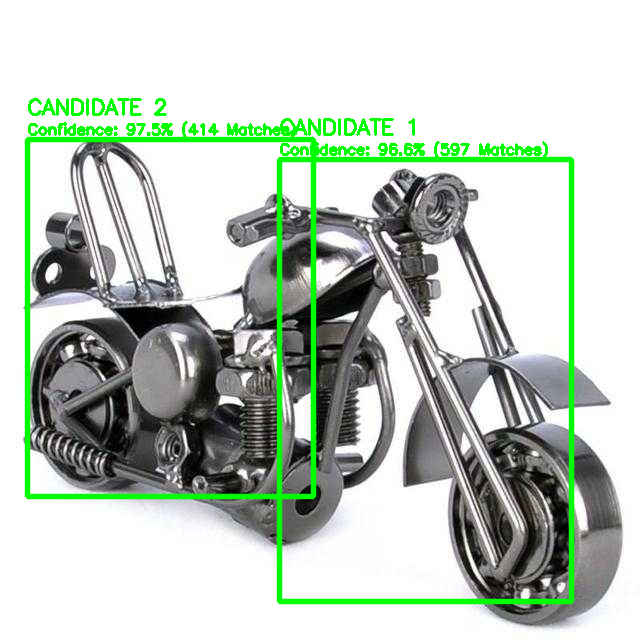


Kotak Hijau menandai 2 lokasi objek yang paling mungkin.


In [13]:
import cv2
import numpy as np
from google.colab import files
from google.colab.patches import cv2_imshow
import time
from sklearn.cluster import KMeans # Menggunakan scikit-learn K-Means lebih stabil untuk fitur float

# --- 1. TAHAP TRAINING: UPLOAD TEMPLATE OBJEK (MULTI-FILE) ---

print("--- TAHAP 1: UPLOAD DATA TRAINING (Template Objek) ---")
print("Silakan unggah SEMUA foto template objek (Misal: 5-10 gambar) sekaligus.")
uploaded_templates = files.upload()

if not uploaded_templates:
    print("Error: Harap unggah setidaknya satu gambar template.")
    des_obj_combined = None
else:
    all_descriptors_obj = []
    # Gunakan ORB untuk fitur yang stabil
    orb = cv2.ORB_create(nfeatures=1000)

    print("\nMemproses fitur dari gambar-gambar template...")

    for filename in uploaded_templates.keys():
        if uploaded_templates[filename]:
            img_temp = cv2.imdecode(np.frombuffer(uploaded_templates[filename], np.uint8), cv2.IMREAD_GRAYSCALE)
            if img_temp is not None:
                kp_temp, des_temp = orb.detectAndCompute(img_temp, None)
                if des_temp is not None:
                    all_descriptors_obj.append(des_temp)
                    print(f"  - {filename}: {len(kp_temp)} fitur terdeteksi.")

    if all_descriptors_obj:
        des_obj_combined = np.vstack(all_descriptors_obj)
        print(f"\nTotal {des_obj_combined.shape[0]} fitur diekstrak dari data training.")
    else:
        print("\n[GAGAL] Tidak ada fitur yang cukup diekstrak dari template.")
        des_obj_combined = None


# --- 2. TAHAP TESTING: UPLOAD GAMBAR ADEGAN KERAMAIAN ---

if des_obj_combined is not None:
    print("\n--- TAHAP 2: UPLOAD GAMBAR ADEGAN (CROWD) ---")
    print("Silakan unggah SATU gambar keramaian (Crowd Image) untuk diuji:")
    uploaded_scene = files.upload()

    if not uploaded_scene:
        print("Error: Harap unggah satu gambar Adegan.")
    else:
        filename_scene = next(iter(uploaded_scene.keys()))

        if uploaded_scene[filename_scene]:
            img_scene_color = cv2.imdecode(np.frombuffer(uploaded_scene[filename_scene], np.uint8), cv2.IMREAD_COLOR)

            if img_scene_color is None:
                print("Error: Gambar adegan tidak dapat dibaca.")
            else:
                img_scene_gray = cv2.cvtColor(img_scene_color, cv2.COLOR_BGR2GRAY)

                # --- 3. EKSTRAKSI FITUR DARI GAMBAR ADEGAN ---
                kp_scene, des_scene = orb.detectAndCompute(img_scene_gray, None)

                if des_scene is None or len(des_scene) < 4:
                    print("\n[GAGAL] Tidak ada fitur yang cukup terdeteksi di gambar keramaian.")
                else:

                    # --- 4. PENCARIAN & PENYARINGAN FITUR (RATIO TEST) ---
                    bf = cv2.BFMatcher()
                    matches_knn = bf.knnMatch(des_obj_combined, des_scene, k=2)

                    good_matches = []
                    RATIO_THRESH = 0.70

                    for m, n in matches_knn:
                        if m.distance < RATIO_THRESH * n.distance:
                            good_matches.append(m)

                    if len(good_matches) < 20: # Minimal 20 kecocokan untuk 2 objek
                        print(f"\n[GAGAL] Hanya {len(good_matches)} kecocokan yang lolos Ratio Test. Minimal 20 diperlukan untuk multi-objek.")
                    else:

                        # --- 5. LOKALISASI MENGGUNAKAN K-MEANS (K=2 OBJEK) ---

                        inlier_points = np.float32([ kp_scene[m.trainIdx].pt for m in good_matches ]).reshape(-1, 2)

                        # Simpan indeks dan jarak dari good_matches
                        inlier_match_data = [(m.trainIdx, m.distance) for m in good_matches]

                        K_OBJECTS = 2 # Target: 2 Bounding Box
                        MIN_POINTS_PER_CLUSTER = 10 # Minimal 10 titik per cluster
                        MAX_ORB_DISTANCE = 256.0 # Jarak Hamming maksimum untuk ORB

                        try:
                            kmeans = KMeans(n_clusters=K_OBJECTS, random_state=42, n_init=10, max_iter=100)
                            labels = kmeans.fit_predict(inlier_points)

                            img_result = img_scene_color.copy()
                            detected_objects = 0
                            H, W, _ = img_scene_color.shape

                            # Loop melalui setiap cluster yang ditemukan
                            for i in range(K_OBJECTS):
                                cluster_points_indices = np.where(labels == i)[0]
                                cluster_points = inlier_points[cluster_points_indices]

                                if len(cluster_points) >= MIN_POINTS_PER_CLUSTER:
                                    detected_objects += 1

                                    # --- PERHITUNGAN CONFIDENCE SCORE BARU (PERSEN) ---

                                    # 1. Hitung average distance cluster
                                    cluster_distances = [d for idx, d in enumerate(inlier_match_data) if labels[idx] == i]
                                    average_distance_cluster = np.mean([d[1] for d in cluster_distances])

                                    # 2. Konversi Average Distance ke Persentase Confidence (0-100%)
                                    # Confidence = (1 - (Avg. Dist / Max. Dist)) * 100
                                    confidence_percent = max(0, (1 - (average_distance_cluster / MAX_ORB_DISTANCE)) * 100)

                                    # --- BOUNDING BOX KETAT ---
                                    min_x, min_y = np.min(cluster_points, axis=0).astype(int)
                                    max_x, max_y = np.max(cluster_points, axis=0).astype(int)

                                    # Terapkan Padding dan Batas Gambar
                                    padding = 10
                                    x1 = max(0, min_x - padding)
                                    y1 = max(0, min_y - padding)
                                    x2 = min(W, max_x + padding)
                                    y2 = min(H, max_y + padding)

                                    box_coords = np.array([[[x1, y1], [x1, y2], [x2, y2], [x2, y1]]], dtype=np.int32)

                                    # Gambar Bounding Box
                                    cv2.polylines(img_result, box_coords, True, (0, 255, 0), 3, cv2.LINE_AA)

                                    # Tambahkan label Confidence Score (di atas Bounding Box)
                                    text_label = f"CANDIDATE {i+1}"
                                    text_conf = f"Confidence: {confidence_percent:.1f}% ({len(cluster_points)} Matches)"
                                    cv2.putText(img_result, text_label, (x1, y1 - 25), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
                                    cv2.putText(img_result, text_conf, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

                            print("\n=============================================")
                            print("      HASIL LOKALISASI MULTI-OBJEK DITEMUKAN")
                            print("=============================================")
                            print(f"Total Objek (Cluster) Ditemukan: {detected_objects}")
                            print(f"Total Match yang Digunakan (Ratio-Filtered): {len(good_matches)}")

                            cv2_imshow(img_result)
                            print("\nKotak Hijau menandai 2 lokasi objek yang paling mungkin.")

                        except ValueError as e:
                            print(f"\n[GAGAL] K-Means gagal. Error: {e}. Coba unggah gambar dengan perbedaan kontras yang lebih jelas.")
                            cv2_imshow(img_scene_color)